In [1]:
import numpy as np
import scipy as sp
from scipy.sparse.linalg import gmres
import matplotlib.pyplot as plt
import time

# Final Project Problem 2

Consider the Burgers' equation
$$u_t+f(u)_x=0,\quad f(u)=\frac{1}{2}u^2$$
for a function $u(x, t)$ with $t\in\mathbb{R}_+$ and $x\in[0, 2]$. The IC is $u(x, 0)=2+\sin(\pi x)$ and we have periodic boundary conditions.

We discretize this equation using a first order finite volume method in space. The numerical flux at the boundaries is the upwind flux
$$f^n_{i+1/2}(u_i, u_{i+1/2}) = f(u_i)$$

We have a grid $x_1,\dots,x_N$ where $x_0=0$ and $x_{N+1}=2$. The edges of the cells are located at these $x$ values. The solution values are defined at the centers of each cell, at $x_{i+1/2}$ for $i=0,\dots,N$. So we have $N+1$ solution values $u_1,\dots,u_{N+1}$. Then the periodic boundary conditions mean that the solution $u_0=u_{N+1}$ and similarly $u_{N+2}=u_1$.

In [2]:
class InexactNewton():
    def __init__(self, Newton_tol, eta_max, preconditioning):
        self.Newton_tol = Newton_tol
        self.eta_max = eta_max
        self.preconditioning = preconditioning
    
    def Eisenstat_Walker(self, k, f_k, f_km1, eta_km1, tol, gamma=1):
        # Calculate the Eisenstat Walker forcing term for iteration k
        eta_C = 0
        f_k_norm = np.linalg.norm(f_k)
        if k==0:
            eta_C = self.eta_max
        else: #k>0
            eta_A = gamma*(f_k_norm**2)/(np.linalg.norm(f_km1)**2)
            gamma_eta_sqr = gamma*eta_km1**2
            if gamma_eta_sqr <= 0.1:
                eta_C = min(self.eta_max, eta_A)
            else:# gamma*eta_km1**2 > 0.1
                eta_C = min(self.eta_max, max(eta_A, gamma_eta_sqr))
        return min(self.eta_max, max(eta_C, tol/(2*f_k_norm)))

In [3]:
class Burgers_FV():
    """
    Solver for the 1D Burgers' equation using a first order finite volume method.
    """
    def __init__(self, L, dx, u_0):
        # u_0 should be a function of x which returns the initial condition across the domain
        # Grid: locations x1,..., xN where x0=0 and xN+1=L
        # Solution values computed at u1,...,uN+1 at locations x_1/2,x_3/2,...,x_N+0.5
        self.L = L
        self.dx = dx
        self.grid = np.arange(self.dx, L, self.dx)
        self.N = len(self.grid)
        self.u_0 = u_0
        self.u_init = self.initialize()
        self.Ncells = len(self.u_init)
        # B is matrix representing upwind flux sparsity pattern
        B = np.diag(np.ones(self.Ncells)*-1, k=0)+np.diag(np.ones(self.Ncells-1), k=-1)
        B[0, -1] = 1
        self.Bfull = B

    def initialize(self):
        # Initialize the solution vector u using u_0
        # Values are computed as averages between edge values
        fullGrid = np.zeros(self.N+2)
        fullGrid[1:-1] = self.grid
        fullGrid[-1] = self.L
        self.cellGrid = 0.5*(fullGrid[:-1]+fullGrid[1:])
        # Compute solution at full grid values
        fullSolution = self.u_0(fullGrid)
        # Return sum of full solution and solution shifted left
        return 0.5*(fullSolution[:-1]+fullSolution[1:])
    # f(u)=u^2/2
    def f(self, u):
        # Flux f(u)
        # u here is scalar value of solution
        return (u**2)/2
    # Eigenvalues of f'(u)=u
    def eigs(self, u):
        # u here is scalar value of solution
        return u
    # B matrix representing sparsity pattern of upwind flux
    def B(self, N):
        if N == self.Ncells:
            return self.Bfull
        B = np.diag(np.ones(N)*-1, k=0)+np.diag(np.ones(N-1), k=-1)
        B[0, -1] = 1
        return B
    # Numerical upwind flux
    def Fn(self, uL, uR):
        return self.f(uL)
    # Numerical flux rhs
    def rhs(self, t, dx, u_n):
        return (0.5/dx)*self.B(len(u_n))@(u_n)**2
    # Numerical flux Jacobian
    def jac_rhs(self, t, dx, u_n):
        return (1/dx)*self.B(len(u_n))@np.diag(u_n, k=0)
    # Newton Jacobian
    def Fprime(self, t, dt, dx, u_n):
        return np.identity(len(u_n)) - dt*self.jac_rhs(t, dx, u_n)
    # Function F(U) where F(U)=0 is the IE solution at the next time step
    def F_IE(self, t, dt, dx, U, u_n):
        return U - u_n - dt*self.rhs(t, dx, U)
    # Jacobian free approx
    def Fprime_approx(self, t, dt, dx, u_n, xk, Fk, v):
        # Approximate F'(xk)v
        vNorm = np.linalg.norm(v)
        if vNorm != 0:
            eps = np.sqrt(1e-16)/vNorm
        else:
            eps = 1e-6
        return (1/eps)*(self.F_IE(t, dt, dx, xk+eps*v, u_n)-Fk)
    def attach_endpoints(self, u_vec, t, update_bcs):
        u_full = np.zeros(len(u_vec)+2)
        u_full[1:len(u_full)-1] = u_vec
        # Set first and last value here according to given update fcn
        left_val, right_val = update_bcs(u_vec, t)
        u_full[0] = left_val
        u_full[-1] = right_val
        return u_full
    # Periodic BCs
    def periodic_bcs(self, u, t):
        # Returns left val, right val
        # left val will be last value in the solution, right val the first
        return u[-1], u[0]
    
    def explicit_Euler(self, u_n, u_full, dt):
        # Perform an EE time step
        # Iterate through edges, adding flux at each to the cell on the right and
        # subtracting it from the cell on the left
        # There are N+3 solution values in the vector now, so N+2 edges between them
        deltas = np.zeros_like(u_n)
        for i in range(len(u_full)-1):
            flux = self.Fn(u_full[i], u_full[i+1])
            # i here is the index of the cell on the right, i-1 the cell on the left
            if i == 0:
                # For the first cell, we don't subtract anything from cell on left
                # since it doesn't exist
                deltas[i] += flux
            elif i==len(u_full)-2:
                # For the last cell, we don't add anything to cell on right
                deltas[i-1] -= flux
            else:
                deltas[i] += flux
                deltas[i-1] -= flux
        # Make the update to un from deltas
        u_np1 = u_n + (dt/self.dx)*deltas
        return u_np1
    
    def Newton_GMRES(self, u0, b0):
        pass

    # 2 stage RK smoother
    def RKSmoother(self, xl, Al, bl, RKdt, steps=3):
        def F(u):
            return bl-Al@u # Alu-bl unstable
        uk = xl.copy()
        for i in range(steps):
            u1 = uk + (1/3)*RKdt*F(uk)
            uk = uk + RKdt*F(u1)
        return uk

    # Multigrid method for preconditioning
    def Multigrid(self, xl, bl, l, t, dt, ul, unl, rhsl):
        # Take initial guess xl and update it to better approximate the solution
        # to Alx*=bl
        # bl is the vector we want to approximate A^-1 bl for, then the residual on lower levels
        # t, dt given for computing jacobian
        # ul is the current Newton guess uk at which we want the Jacobian
        # unl is the value u_n at the previous time step, used in JF approximation
        # rhsl is the current rhs F(uk) in Newton, used in JF approximation
        n = len(xl)
        dxl = self.L / n # dx for this level
        # Jacobian Al for this level, constructed from representation
        # of current Newton solution at this level
        Al = self.Fprime(t, dt, dxl, ul)
        # Jacobian free approximation of Al
        # Wrap JF approx of Fprime
        #def JFFPrime(x):
        #    return self.Fprime_approx(t, dt, dxl, unl, ul, rhsl, x)
        #AlJF = sp.sparse.linalg.LinearOperator((n, n), JFFPrime)
        if l==0:
            # Solve A0x0=b0 exactly and return x0, or do a few CGC iterations?
            return np.linalg.solve(Al, bl)
        else:
            # Restriction and Prolongation for this level
            if n/2 != n//2:
                raise ValueError("Multigrid must be performed on even number of unknowns")
            R = np.zeros((n//2, n))
            for i in range(R.shape[0]):
                R[i, 2*i:2*i+2] = 0.5
            P = 2*R.T
            # Choose RK pseudo time step based on upper bound for eigs of Al
            # dt* = (CFL/2)*(dx/max(ul)) = (1.5/2)*(dx/max(ul))
            RKdt = 0.9*(3/4)*(dxl/np.max(abs(ul)))
            xl = self.RKSmoother(xl, Al, bl, RKdt) # Presmoothing
            rlm1 = R@(Al@xl-bl) # Restrict residual
            vlm1 = np.zeros(len(rlm1)) # Guess at next error
            ulm1 = R@ul # Restrict Newton solution to coarser grid
            rhslm1 = R@rhsl # Restrict Newton rhs to coarser grid
            unlm1 = R@unl # Restrict current guess at Newton solution
            # Recursion - W cycle helps get mesh independent convergence
            for i in range(2):
                vlm1 = self.Multigrid(vlm1, rlm1, l-1, t, dt, ulm1, unlm1, rhslm1)
            xl = xl-P@vlm1 # Prolongate error back and adjust x
            xl = self.RKSmoother(xl, Al, bl, RKdt) # Postsmoothing, also helps GMRES convergence
            return xl

    def implicit_Euler(self, u_n, t, dt, Newton):
        # Perform an IE time step
        # Newton GMRES method
        n = self.Ncells
        uk = u_n.copy()            # Initial guess
        bk = -dt*self.rhs(t, self.dx, uk)     # Initial rhs, from implicit Euler update
        res_k = np.linalg.norm(bk)   # Initial residual
        
        k = 0 # Iteration
        bkm1 = None # Previous rhs at iteration k-1
        eta_km1 = None # Previous forcing term at iteration k-1
        eta_k = None # Forcing term for iteration k

        kth_gmres_iters = 0 # Number of total gmres iterations for this time step (called multiple times per time step)
        while res_k > Newton.Newton_tol:
            if k > 10**3:
                print("Max iterations reached without convergence")
                break
            # Jacobian Ak at current iterate
            #Ak = self.Fprime(t, dt, self.dx, uk)
            # Create operator approximating Ak
            # Wrap JF approx of Fprime
            def JFFPrime(x):
                return self.Fprime_approx(t, dt, self.dx, u_n, uk, bk, x)
            AkJF = sp.sparse.linalg.LinearOperator((n, n), JFFPrime)

            ###################################
            # Preconditioner
            ###################################
            M = None # Linear operator for approximating A_inv @ x operations
            if Newton.preconditioning == 'jacobi':
                Ak = self.Fprime(t, dt, self.dx, uk)
                def jacobi_matvec(x):
                    # Should return M@x ~= A_inv@x using M=D_inv where A=L+D+U
                    D_inv = sp.sparse.diags(1/Ak.diagonal(), offsets=0)
                    return D_inv@x
                # Create linear operator
                M = sp.sparse.linalg.LinearOperator((n, n), matvec=jacobi_matvec)
            elif Newton.preconditioning == 'ilu':
                Ak = self.Fprime(t, dt, self.dx, uk)
                # Incomplete LU decomp using spilu from scipy
                ilu = sp.sparse.linalg.spilu(Ak)
                # Create linear operator
                M = sp.sparse.linalg.LinearOperator((n, n), matvec=ilu.solve)
            elif Newton.preconditioning == 'multigrid':
                # Multigrid preconditioning
                # Wrap so all that is given is vector x
                MGDepth = 0
                dofs = len(uk)
                while dofs/2 == dofs//2:
                    if dofs < 25:
                        break
                    dofs /= 2
                    MGDepth += 1
                #print(f"Coursest grid: {int(dofs)} unknowns")
                #print(f"Multigrid depth: {MGDepth}")
                if dofs >= 128:
                    print(f"Warning, can only reduce system to {int(dofs)} unknowns, consider using grid length which is a power of 2.")
                def MG(x):
                    x1 = np.zeros_like(uk)
                    #t0 = time.time()
                    for i in range(3):
                        x1 = self.Multigrid(x1, x, MGDepth, t, dt, uk, u_n, bk)
                    #print(f"Avg time per MG iteration: {(time.time()-t0)/3}")
                    return x1
                M = sp.sparse.linalg.LinearOperator((n, n), matvec=MG)
            elif Newton.preconditioning is not None:
                raise ValueError(f"Unknown preconditioning \"{Newton.preconditioning}\" specified")
            
            # Solve linear system using gmres
            class Increment_GMRES():
                def __init__(self):
                    self.iters = 0
                def increment(self, args=None):
                    self.iters += 1
            inc_GMRES = Increment_GMRES()
            
            # GMRES method, passing in left preconditioner (if specified)
            # Eisenstat Walker
            eta_km1 = eta_k # Before we update eta, save last value
            eta_k = Newton.Eisenstat_Walker(k, bk, bkm1, eta_km1, tol=Newton.Newton_tol, gamma=1.0)
            if M is None:
                #t0 = time.time()
                du, exitCode = gmres(AkJF, -bk, rtol=eta_k, callback=inc_GMRES.increment, callback_type='pr_norm', maxiter=10**2)
                #print(f"Spent {time.time()-t0} s in GMRES")
            else: # Use linear operator M
                #t0 = time.time()
                du, exitCode = gmres(AkJF, -bk, rtol=eta_k, M=M, callback=inc_GMRES.increment, callback_type='pr_norm', maxiter=10**2)
                if exitCode != 0:
                    print(f"GMRES failed to converge")
                #print(f"Spent {time.time()-t0} s in GMRES")
            kth_gmres_iters += inc_GMRES.iters
            # Update Newton solution and residual
            uk = uk + du
            bkm1 = bk.copy() # Save rhs at k-1 for next iteration
            bk = self.F_IE(t, dt, self.dx, uk, u_n)
            res_k = np.linalg.norm(bk)

            k += 1
        un = uk.copy()
        return un, k, kth_gmres_iters
    
    def testMultigrid(self, dt, iters):
        # Test the MG method by using it as a solver at the first time step
        u_n = self.initialize()
        bk = -dt*self.rhs(0, self.dx, u_n)
        Ak = self.Fprime(0, dt, self.dx, u_n)
        #solution = -1*np.linalg.inv(Ak)@bk
        # We want to test on problem Akx*=-bk
        residuals = []
        xk = np.zeros_like(u_n) # Guess
        residuals.append(np.linalg.norm(Ak@xk+bk))
        MGDepth = 0
        dofs = len(u_n)
        while dofs/2 == dofs//2:
            if dofs < 25:
                break
            dofs /= 2
            MGDepth += 1
        for i in range(iters):
            xk = self.Multigrid(xk, -bk, MGDepth, 0, dt, u_n, u_n, bk)
            residuals.append(np.linalg.norm(Ak@xk+bk))
        #print(f"Solution: {solution[:10]}")
        return residuals


    # Time loop
    def integrate(self, tf, dt, update_bcs=None, solver="explicitEuler", Newton=None, concat_endpoints=False, save_interval=None):
        # update_bcs should be a function which takes u and t and returns boundary values
        # for the current time. If None, assume periodic
        # Newton contains parameters for inexact Newton method, including the tolerance, eta_max for
        # Eisenstat Walker, and preconditioning method to use. Only used in implicit method.
        if update_bcs is None:
            update_bcs = self.periodic_bcs
        t=0
        self.dt = dt
        # Initialize u
        u_n = self.initialize()
        u_history = [u_n]
        t_history = [0]
        j = 0
        if save_interval is None:
            save_interval = tf/10
        print_time = save_interval
        interval = save_interval
        max_iters = 10**4
        newton_iters = []
        gmres_iters = []
        while True:
            if t >= tf:
                break
            if t >= print_time:
                print(f"Time t={t}, dt={dt}")
                print_time += interval
                # Append solution and time
                if concat_endpoints:
                    u_history.append(self.attach_endpoints(u_n, t, update_bcs))
                else:
                    u_history.append(u_n)
                t_history.append(t)
            u_np1 = np.zeros_like(u_n)
            if solver=='explicitEuler':
                # First, append boundary values to u vector
                u_full = self.attach_endpoints(u_n, t, update_bcs)
                u_np1 = self.explicit_Euler(u_n, u_full, dt)
            elif solver=='implicitEuler':
                u_np1, newton_it, gmres_it = self.implicit_Euler(u_n, t, dt, Newton)
                newton_iters.append(newton_it)
                gmres_iters.append(gmres_it)
            else:
                raise ValueError(f"Unknown solver: {solver}")

            # Update time
            t += dt
            if t+dt > tf:
                dt = tf-t
            # Update u_n    
            u_n = u_np1.copy()
            
            j += 1
            if j>max_iters:
                print("Maximum iterations reached")
                break
        # Append bcs onto the solution
        if concat_endpoints:
            u_np1 = self.attach_endpoints(u_np1, t, update_bcs)
            # If I want to append grid ends here, I have to figure out whether to interpolate at x=0 and L
            # or just give the periodic endpoints which are not at these edges exactly
        else:
            grid = self.cellGrid
        # Append last solution to history
        print(f"Time t={t}, dt={dt}")
        u_history.append(u_np1)
        t_history.append(t)
        if solver=='implicitEuler':
            return u_history, t_history, grid, newton_iters, gmres_iters
        elif solver=='explicitEuler':
            return u_history, t_history, grid

In [4]:
L = 2
dx = 0.001
@np.vectorize
def u_0_sine(x):
    return 2+np.sin(np.pi*x)
# Create solver
u_0 = u_0_sine
BurgersSolver = Burgers_FV(L, dx, u_0)

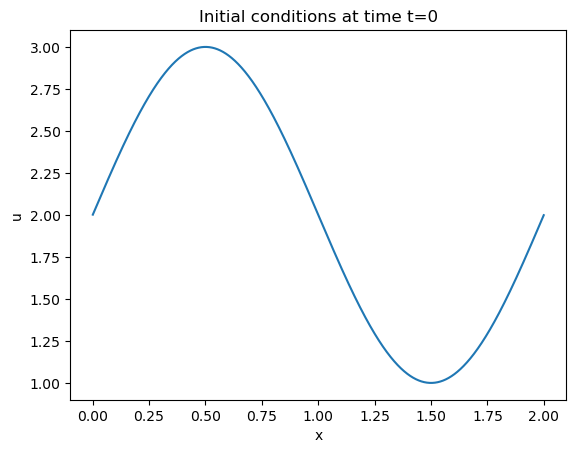

In [5]:
fig, ax = plt.subplots(1, 1)
ax.plot(BurgersSolver.cellGrid, BurgersSolver.u_init)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Initial conditions at time t=0")
plt.show()

## Explicit Euler

Time t=0.050100000000000186, dt=0.0003
Time t=0.1001999999999996, dt=0.0003
Time t=0.1502999999999987, dt=0.0003
Time t=0.20009999999999784, dt=0.0003
Time t=0.250199999999997, dt=0.0003
Time t=0.3000000000000007, dt=0.0003
Time t=0.35010000000000446, dt=0.0003
Time t=0.4002000000000082, dt=0.0003
Time t=0.45000000000001195, dt=0.0003
Time t=0.5001000000000156, dt=0.0003
Time t=0.5502000000000101, dt=0.0003
Time t=0.6000000000000046, dt=0.0003
Time t=0.6500999999999991, dt=0.0003
Time t=0.7001999999999936, dt=0.0003
Time t=0.7502999999999881, dt=0.0003
Time t=0.8000999999999826, dt=0.0003
Time t=0.8501999999999771, dt=0.0003
Time t=0.9002999999999716, dt=0.0003
Time t=0.9500999999999661, dt=0.0003
Time t=1.0001999999999607, dt=0.0003
Time t=1.0502999999999552, dt=0.0003
Time t=1.1000999999999497, dt=0.0003
Time t=1.1501999999999442, dt=0.0003
Time t=1.2002999999999386, dt=0.0003
Time t=1.2500999999999332, dt=0.0003
Time t=1.3001999999999276, dt=0.0003
Time t=1.3502999999999221, dt=0.00

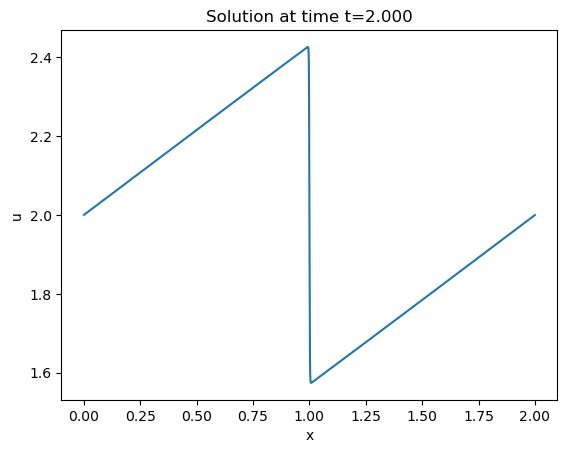

In [6]:
# Integrate with EE
L = 2
dx = 0.001
@np.vectorize
def u_0_sine(x):
    return 2+np.sin(np.pi*x)
# Create solver
u_0 = u_0_sine
BurgersSolver = Burgers_FV(L, dx, u_0)
tf = 2
dt = 0.3*dx
u_hist, t_hist, grid = BurgersSolver.integrate(tf, dt, solver='explicitEuler', save_interval=tf/40)
u = u_hist[-1]
t = t_hist[-1]
print(f"Solution shape: {u.shape}, final time: {t}")
print(f"dt/dx: {BurgersSolver.dt/BurgersSolver.dx:.3f}")
fig, ax = plt.subplots(1, 1)
ax.plot(grid, u)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Solution at time t={t:.3f}")
plt.show()

In [7]:
# Try to create an animation
%matplotlib inline
import matplotlib.animation as animation
fig, ax = plt.subplots(1, 1)
line = ax.plot(grid, u_hist[0])[0]
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Solution at time t={t_hist[0]:.3f}")

def update(frame):
    line.set_ydata(u_hist[frame])
    ax.set_title(f"Solution at time t={t_hist[frame]:.3f}")

anim = animation.FuncAnimation(fig=fig, func=update, frames=len(u_hist), interval=100)

from IPython.display import HTML
plt.close()
HTML(anim.to_jshtml())
#anim.save(r"C:\Users\Colin\Documents\School\NUMN28\FinalProject\Figures\EEAnim.gif")

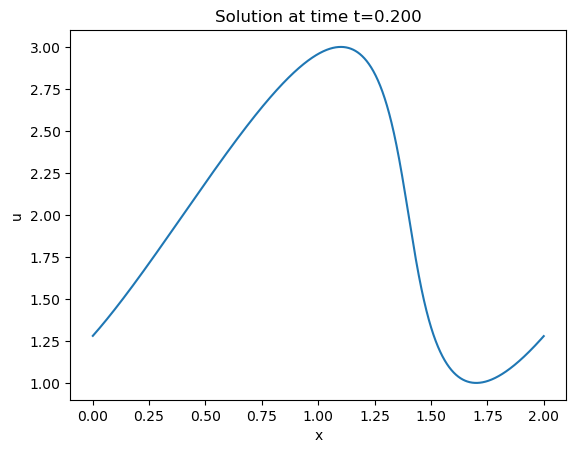

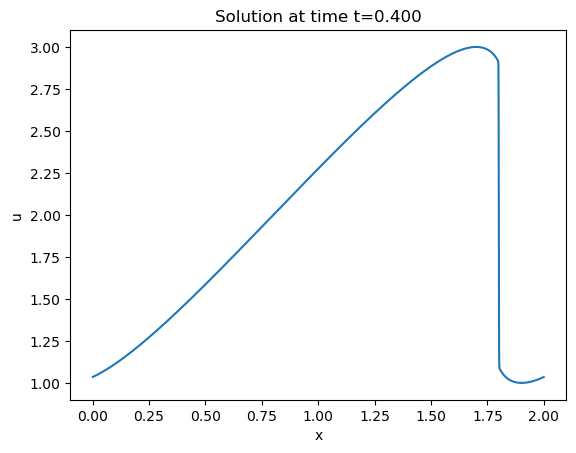

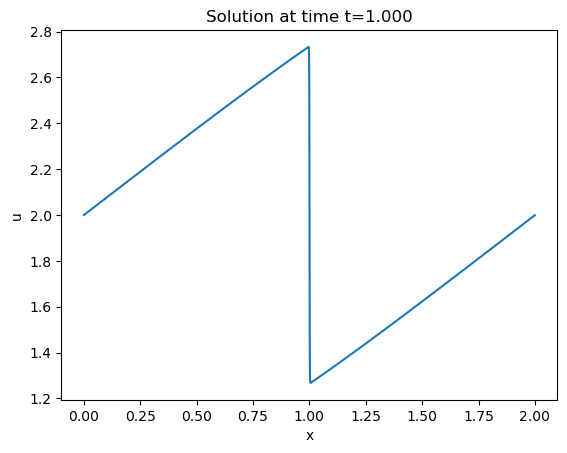

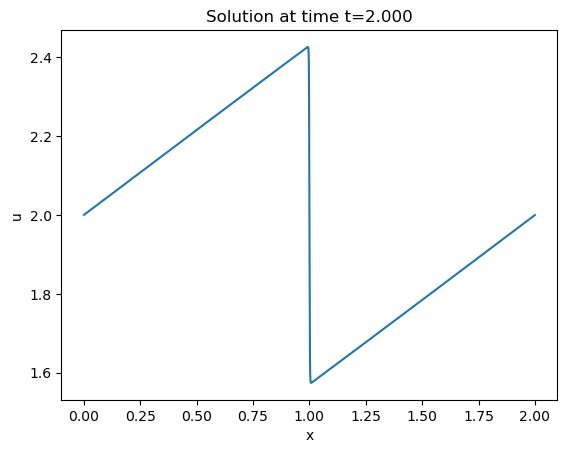

In [8]:
for ind in [4, 8, 20, -1]:
    fig, ax = plt.subplots(1, 1)
    ax.plot(grid, u_hist[ind])
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.set_title(f"Solution at time t={t_hist[ind]:.3f}")
    plt.show()

## Implicit Euler

Time t=0.1, dt=0.1
Time t=0.2, dt=0.1
Time t=0.30000000000000004, dt=0.1
Time t=0.4, dt=0.1
Time t=0.5, dt=0.1
Time t=0.6, dt=0.1
Time t=0.7, dt=0.1
Time t=0.7999999999999999, dt=0.1
Time t=0.8999999999999999, dt=0.1
Time t=0.9999999999999999, dt=0.1
Time t=1.0999999999999999, dt=0.1
Time t=1.2, dt=0.1
Time t=1.3, dt=0.1
Time t=1.4000000000000001, dt=0.1
Time t=1.5000000000000002, dt=0.1
Time t=1.6000000000000003, dt=0.1
Time t=1.7000000000000004, dt=0.1
Time t=1.8000000000000005, dt=0.1
Time t=1.9000000000000006, dt=0.09999999999999942
Time t=2.0, dt=0.0
Solution shape: (200,), final time: 2.0
dt/dx: 10.000


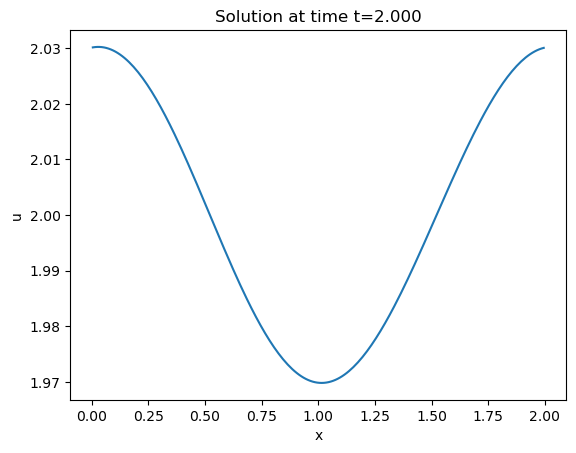

In [9]:
L = 2
dx = 0.01
@np.vectorize
def u_0_sine(x):
    return 2+np.sin(np.pi*x)
# Create solver
u_0 = u_0_sine
BurgersSolver = Burgers_FV(L, dx, u_0)
# Newton params
Newton = InexactNewton(Newton_tol=1e-10, eta_max=0.9, preconditioning='multigrid')
# Integrate with IE
tf = 2
dt = tf/20
u_hist, t_hist, grid, newton_iters, gmres_iters = BurgersSolver.integrate(tf, dt, solver='implicitEuler', Newton=Newton, save_interval=tf/40)
u = u_hist[-1]
t = t_hist[-1]
print(f"Solution shape: {u.shape}, final time: {t}")
print(f"dt/dx: {BurgersSolver.dt/BurgersSolver.dx:.3f}")
fig, ax = plt.subplots(1, 1)
ax.plot(grid, u)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Solution at time t={t:.3f}")
plt.show()

In [10]:
# Create an animation
%matplotlib inline
import matplotlib.animation as animation
fig, ax = plt.subplots(1, 1)
line = ax.plot(grid, u_hist[0])[0]
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Solution at time t={t_hist[0]:.3f}")

def update(frame):
    line.set_ydata(u_hist[frame])
    ax.set_title(f"Solution at time t={t_hist[frame]:.3f}")

anim = animation.FuncAnimation(fig=fig, func=update, frames=len(u_hist), interval=150)

from IPython.display import HTML
plt.close()
HTML(anim.to_jshtml())
#anim.save(r"C:\Users\Colin\Documents\School\NUMN28\FinalProject\Figures\IEAnimLargeDt.gif")

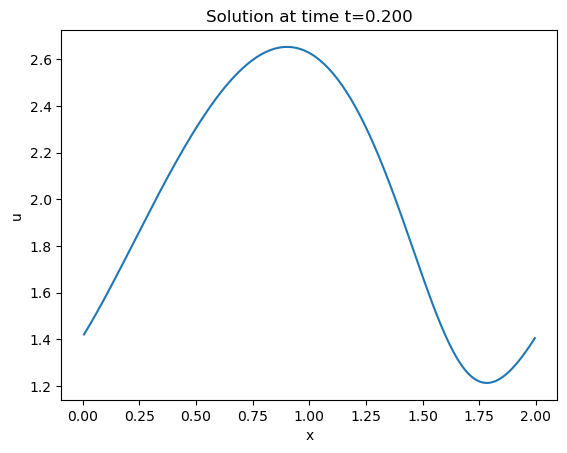

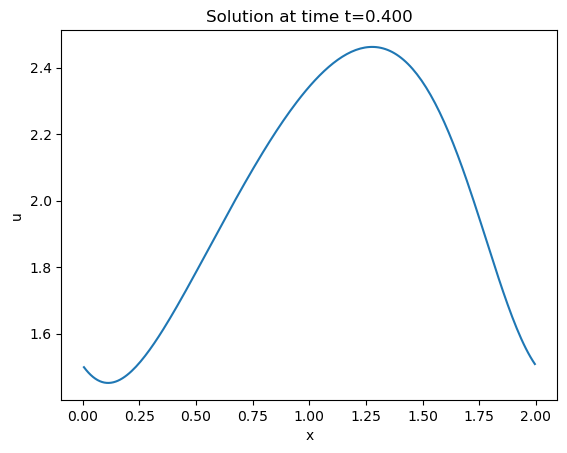

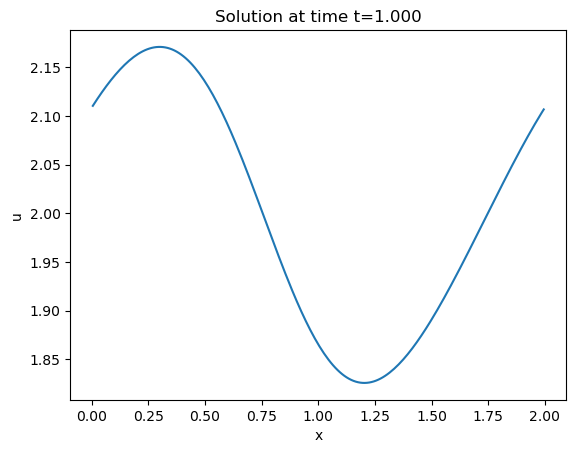

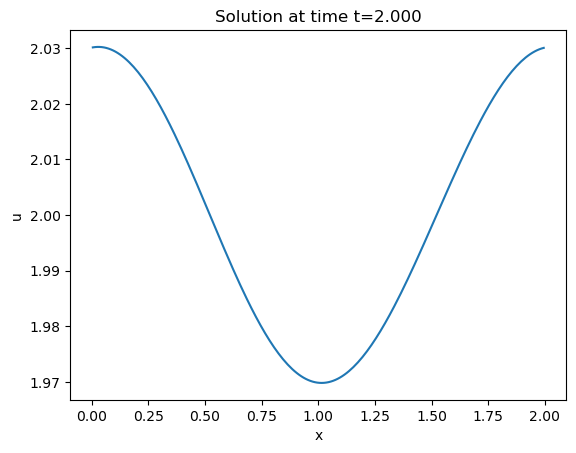

In [11]:
for ind in [2, 4, 10, -1]:
    fig, ax = plt.subplots(1, 1)
    ax.plot(grid, u_hist[ind])
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.set_title(f"Solution at time t={t_hist[ind]:.3f}")
    plt.show()

### GMRES stats

In [12]:
# Gather stats on number of iterations per time step for Newton and GMRES for varying time steps
# Plot for no precond, jacobi, and ilu preconditioning
dts = [0.01, 0.05, 0.1, 0.15, 0.2]
precons = [None, 'multigrid']
newton_avgs = []
newton_totals = []
gmres_avgs = []
gmres_totals = []
L = 2
dx = 0.01
BurgersSolver = Burgers_FV(L, dx, u_0)
for j, precon in enumerate(precons):
    Newton = InexactNewton(Newton_tol=1e-10, eta_max=0.9, preconditioning=precon) # Be wary of tolerance and eta combination, some don't converge
    print(f"preconditioning: {precon}")
    print(f"TOL: {Newton.Newton_tol}")
    for i in range(len(dts)):
        # Integrate with IE
        tf = 1
        u_hist, t_hist, grid, n_iters, g_iters = BurgersSolver.integrate(tf, dts[i], solver='implicitEuler', Newton=Newton, save_interval=tf/40)
        newton_avgs.append(np.mean(n_iters))
        newton_totals.append(sum(n_iters))
        gmres_avgs.append(np.mean(g_iters))
        gmres_totals.append(sum(g_iters))

preconditioning: None
TOL: 1e-10
Time t=0.03, dt=0.01
Time t=0.05, dt=0.01
Time t=0.08, dt=0.01
Time t=0.10999999999999999, dt=0.01
Time t=0.12999999999999998, dt=0.01
Time t=0.15, dt=0.01
Time t=0.18000000000000002, dt=0.01
Time t=0.20000000000000004, dt=0.01
Time t=0.23000000000000007, dt=0.01
Time t=0.25000000000000006, dt=0.01
Time t=0.2800000000000001, dt=0.01
Time t=0.3000000000000001, dt=0.01
Time t=0.3300000000000001, dt=0.01
Time t=0.35000000000000014, dt=0.01
Time t=0.38000000000000017, dt=0.01
Time t=0.4000000000000002, dt=0.01
Time t=0.4300000000000002, dt=0.01
Time t=0.45000000000000023, dt=0.01
Time t=0.48000000000000026, dt=0.01
Time t=0.5000000000000002, dt=0.01
Time t=0.5300000000000002, dt=0.01
Time t=0.5500000000000003, dt=0.01
Time t=0.5800000000000003, dt=0.01
Time t=0.6000000000000003, dt=0.01
Time t=0.6300000000000003, dt=0.01
Time t=0.6500000000000004, dt=0.01
Time t=0.6800000000000004, dt=0.01
Time t=0.7000000000000004, dt=0.01
Time t=0.7300000000000004, dt=0.0

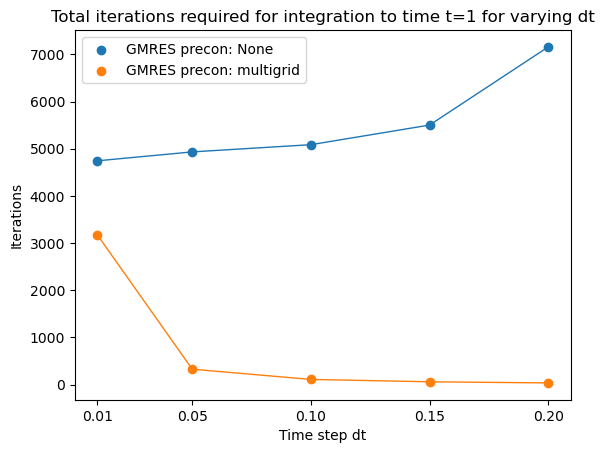

In [13]:
# Plot the total iterations to integrate to end vs time step size
fig, ax = plt.subplots(1, 1)
for i in range(len(precons)):
    #ax.scatter(dts, newton_totals[i*len(dts):(i+1)*len(dts)], label=f"Newton precon: {precons[i]}")
    #ax.plot(dts, newton_totals[i*len(dts):(i+1)*len(dts)], lw=1)
    ax.scatter(dts, gmres_totals[i*len(dts):(i+1)*len(dts)], label=f"GMRES precon: {precons[i]}")
    ax.plot(dts, gmres_totals[i*len(dts):(i+1)*len(dts)], lw=1)
    ax.set_xticks(dts)
    ax.set_title(rf"Total iterations required for integration to time t={tf} for varying dt")
    ax.set_xlabel("Time step dt")
    ax.set_ylabel("Iterations")
    ax.legend()
plt.show()

preconditioning: None
TOL: 1e-10
Time t=0.03, dt=0.01
Time t=0.05, dt=0.01
Time t=0.08, dt=0.01
Time t=0.10999999999999999, dt=0.01
Time t=0.12999999999999998, dt=0.01
Time t=0.15, dt=0.01
Time t=0.18000000000000002, dt=0.01
Time t=0.20000000000000004, dt=0.01
Time t=0.23000000000000007, dt=0.01
Time t=0.25000000000000006, dt=0.01
Time t=0.2800000000000001, dt=0.01
Time t=0.3000000000000001, dt=0.01
Time t=0.3300000000000001, dt=0.01
Time t=0.35000000000000014, dt=0.01
Time t=0.38000000000000017, dt=0.01
Time t=0.4000000000000002, dt=0.01
Time t=0.4300000000000002, dt=0.01
Time t=0.45000000000000023, dt=0.01
Time t=0.48000000000000026, dt=0.01
Time t=0.5000000000000002, dt=0.01
Time t=0.5300000000000002, dt=0.01
Time t=0.5500000000000003, dt=0.01
Time t=0.5800000000000003, dt=0.01
Time t=0.6000000000000003, dt=0.01
Time t=0.6300000000000003, dt=0.01
Time t=0.6500000000000004, dt=0.01
Time t=0.6800000000000004, dt=0.01
Time t=0.7000000000000004, dt=0.01
Time t=0.7300000000000004, dt=0.0

C:\Users\Colin\AppData\Local\Temp\ipykernel_23096\66240486.py:209: SparseEfficiencyWarning: spilu converted its input to CSC format
  ilu = sp.sparse.linalg.spilu(Ak)


Time t=0.2800000000000001, dt=0.01
Time t=0.3000000000000001, dt=0.01
Time t=0.3300000000000001, dt=0.01
Time t=0.35000000000000014, dt=0.01
Time t=0.38000000000000017, dt=0.01
Time t=0.4000000000000002, dt=0.01
Time t=0.4300000000000002, dt=0.01
Time t=0.45000000000000023, dt=0.01
Time t=0.48000000000000026, dt=0.01
Time t=0.5000000000000002, dt=0.01
Time t=0.5300000000000002, dt=0.01
Time t=0.5500000000000003, dt=0.01
Time t=0.5800000000000003, dt=0.01
Time t=0.6000000000000003, dt=0.01
Time t=0.6300000000000003, dt=0.01
Time t=0.6500000000000004, dt=0.01
Time t=0.6800000000000004, dt=0.01
Time t=0.7000000000000004, dt=0.01
Time t=0.7300000000000004, dt=0.01
Time t=0.7500000000000004, dt=0.01
Time t=0.7800000000000005, dt=0.01
Time t=0.8000000000000005, dt=0.01
Time t=0.8300000000000005, dt=0.01
Time t=0.8500000000000005, dt=0.01
Time t=0.8800000000000006, dt=0.01
Time t=0.9000000000000006, dt=0.01
Time t=0.9300000000000006, dt=0.01
Time t=0.9500000000000006, dt=0.01
Time t=0.9800000

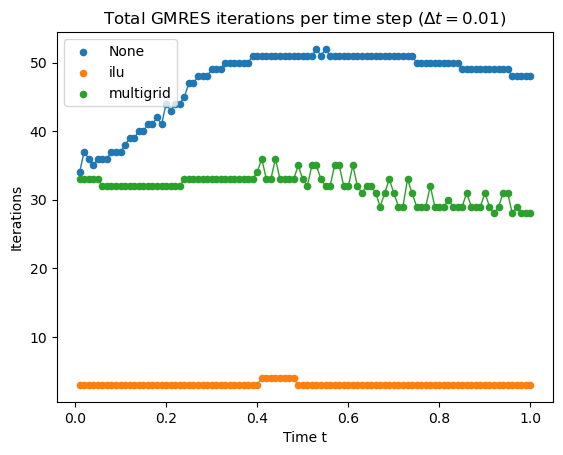

preconditioning: None
TOL: 1e-10
Time t=0.05, dt=0.05
Time t=0.1, dt=0.05
Time t=0.15000000000000002, dt=0.05
Time t=0.2, dt=0.05
Time t=0.25, dt=0.05
Time t=0.3, dt=0.05
Time t=0.35, dt=0.05
Time t=0.39999999999999997, dt=0.05
Time t=0.44999999999999996, dt=0.05
Time t=0.49999999999999994, dt=0.05
Time t=0.5499999999999999, dt=0.05
Time t=0.6, dt=0.05
Time t=0.65, dt=0.05
Time t=0.7000000000000001, dt=0.05
Time t=0.7500000000000001, dt=0.05
Time t=0.8000000000000002, dt=0.05
Time t=0.8500000000000002, dt=0.05
Time t=0.9000000000000002, dt=0.05
Time t=0.9500000000000003, dt=0.04999999999999971
Time t=1.0, dt=0.0
preconditioning: ilu
TOL: 1e-10
Time t=0.05, dt=0.05
Time t=0.1, dt=0.05
Time t=0.15000000000000002, dt=0.05
Time t=0.2, dt=0.05
Time t=0.25, dt=0.05
Time t=0.3, dt=0.05
Time t=0.35, dt=0.05
Time t=0.39999999999999997, dt=0.05
Time t=0.44999999999999996, dt=0.05
Time t=0.49999999999999994, dt=0.05
Time t=0.5499999999999999, dt=0.05
Time t=0.6, dt=0.05
Time t=0.65, dt=0.05
Time 

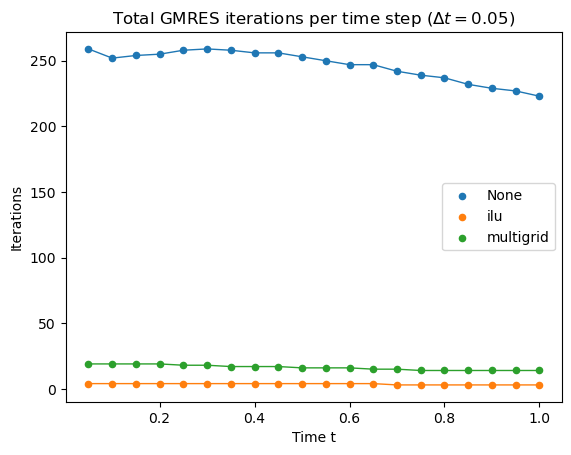

preconditioning: None
TOL: 1e-10
Time t=0.1, dt=0.1
Time t=0.2, dt=0.1
Time t=0.30000000000000004, dt=0.1
Time t=0.4, dt=0.1
Time t=0.5, dt=0.1
Time t=0.6, dt=0.1
Time t=0.7, dt=0.1
Time t=0.7999999999999999, dt=0.1
Time t=0.8999999999999999, dt=0.1
Time t=0.9999999999999999, dt=1.1102230246251565e-16
Time t=1.0, dt=1.1102230246251565e-16
preconditioning: ilu
TOL: 1e-10
Time t=0.1, dt=0.1
Time t=0.2, dt=0.1
Time t=0.30000000000000004, dt=0.1
Time t=0.4, dt=0.1
Time t=0.5, dt=0.1
Time t=0.6, dt=0.1
Time t=0.7, dt=0.1
Time t=0.7999999999999999, dt=0.1
Time t=0.8999999999999999, dt=0.1
Time t=0.9999999999999999, dt=1.1102230246251565e-16
Time t=1.0, dt=1.1102230246251565e-16
preconditioning: multigrid
TOL: 1e-10
Time t=0.1, dt=0.1
Time t=0.2, dt=0.1
Time t=0.30000000000000004, dt=0.1
Time t=0.4, dt=0.1
Time t=0.5, dt=0.1
Time t=0.6, dt=0.1
Time t=0.7, dt=0.1
Time t=0.7999999999999999, dt=0.1
Time t=0.8999999999999999, dt=0.1
Time t=0.9999999999999999, dt=1.1102230246251565e-16
Time t=1.0,

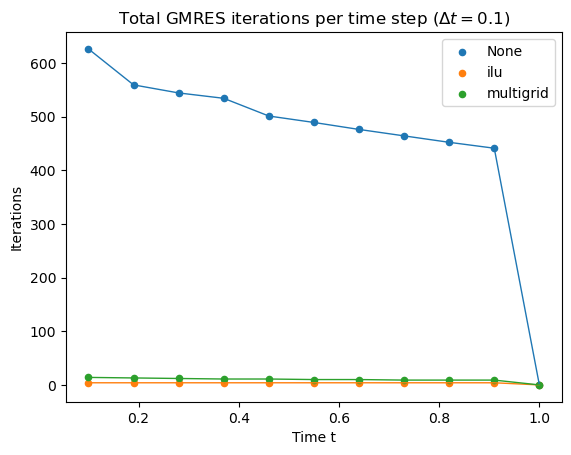

preconditioning: None
TOL: 1e-10
Time t=0.15, dt=0.15
Time t=0.3, dt=0.15
Time t=0.44999999999999996, dt=0.15
Time t=0.6, dt=0.15
Time t=0.75, dt=0.15
Time t=0.9, dt=0.09999999999999998
Time t=1.0, dt=0.0
preconditioning: ilu
TOL: 1e-10
Time t=0.15, dt=0.15
Time t=0.3, dt=0.15
Time t=0.44999999999999996, dt=0.15
Time t=0.6, dt=0.15
Time t=0.75, dt=0.15
Time t=0.9, dt=0.09999999999999998
Time t=1.0, dt=0.0
preconditioning: multigrid
TOL: 1e-10
Time t=0.15, dt=0.15
Time t=0.3, dt=0.15
Time t=0.44999999999999996, dt=0.15
Time t=0.6, dt=0.15
Time t=0.75, dt=0.15
Time t=0.9, dt=0.09999999999999998
Time t=1.0, dt=0.0


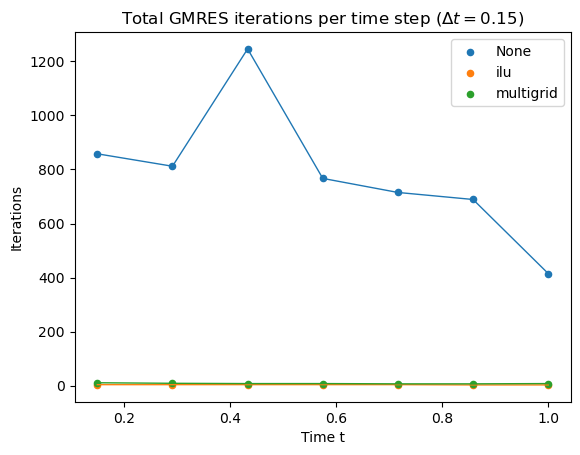

preconditioning: None
TOL: 1e-10
Time t=0.2, dt=0.2
Time t=0.4, dt=0.2
Time t=0.6000000000000001, dt=0.2
Time t=0.8, dt=0.2
Time t=1.0, dt=0.0
preconditioning: ilu
TOL: 1e-10
Time t=0.2, dt=0.2
Time t=0.4, dt=0.2
Time t=0.6000000000000001, dt=0.2
Time t=0.8, dt=0.2
Time t=1.0, dt=0.0
preconditioning: multigrid
TOL: 1e-10
Time t=0.2, dt=0.2
Time t=0.4, dt=0.2
Time t=0.6000000000000001, dt=0.2
Time t=0.8, dt=0.2
Time t=1.0, dt=0.0


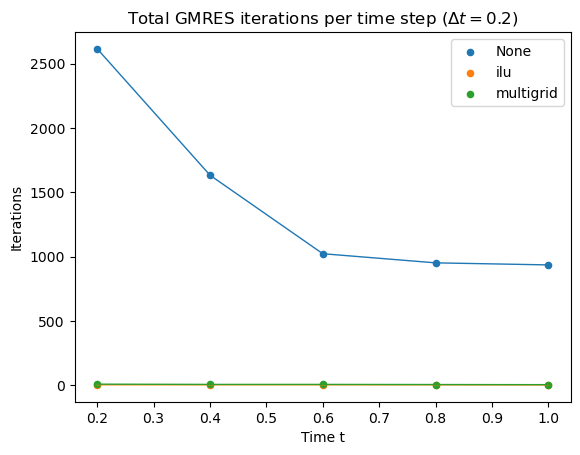

In [14]:
dts = [0.01, 0.05, 0.1, 0.15, 0.2]
precons = [None, 'ilu', 'multigrid']
L = 2
dx = 0.01
BurgersSolver = Burgers_FV(L, dx, u_0)
for i in range(len(dts)):
    fig, ax = plt.subplots(1, 1)
    for j, precon in enumerate(precons):
        Newton = InexactNewton(Newton_tol=1e-10, eta_max=0.9, preconditioning=precon)
        print(f"preconditioning: {precon}")
        print(f"TOL: {Newton.Newton_tol}")
        # Integrate with IE
        tf = 1
        u_hist, t_hist, grid, n_iters, g_iters = BurgersSolver.integrate(tf, dts[i], solver='implicitEuler', Newton=Newton, save_interval=tf/40)
        #ax.scatter(numpy.linspace(dts[i], endTime, len(newton_iters)), newton_iters, label="Newton", s=20)
        #ax.plot(numpy.linspace(deltaT, endTime, len(newton_iters)), newton_iters, lw=1)
        #ax.plot(numpy.linspace(deltaT, endTime, len(newton_iters)), newton_iters, label="Newton")
        ax.scatter(np.linspace(dts[i], tf, len(g_iters)), g_iters, label=fr"{precon}", s=20)
        ax.plot(np.linspace(dts[i], tf, len(g_iters)), g_iters, lw=1)
    ax.set_title(rf"Total GMRES iterations per time step ($\Delta t=${dts[i]})")
    ax.set_xlabel("Time t")
    ax.set_ylabel("Iterations")
    #ax.set_yticks(numpy.arange(5*(min(min(newton_iters), min(gmres_iters))//5), 5*(max(max(newton_iters), max(gmres_iters))//5)+10, 10))
    ax.legend()
    plt.show()

### MG convergence

Residuals: [np.float64(0.20116778119455844), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17)]


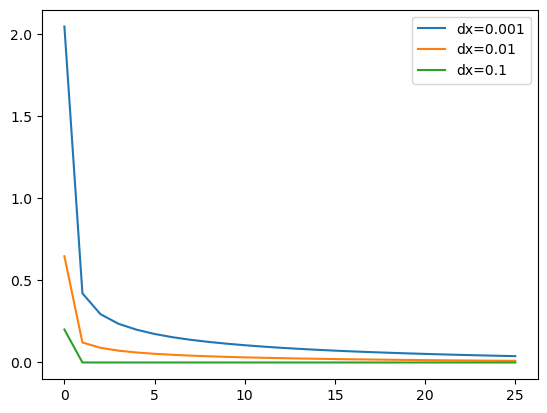

In [15]:
# Test convergence of multigrid
fig, ax = plt.subplots(1, 1)
L = 2
dxs = [0.001, 0.01, 0.1]
for i in range(len(dxs)):
    BurgersSolver = Burgers_FV(L, dxs[i], u_0)
    residuals = BurgersSolver.testMultigrid(dt=0.01, iters=25)
    ax.plot(np.arange(len(residuals)), residuals, label=f"dx={dxs[i]}")
ax.legend()
print(f"Residuals: {residuals}")
plt.show()

Residuals: [np.float64(0.20116778119455844), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.9079264368403834e-17), np.float64(2.907926

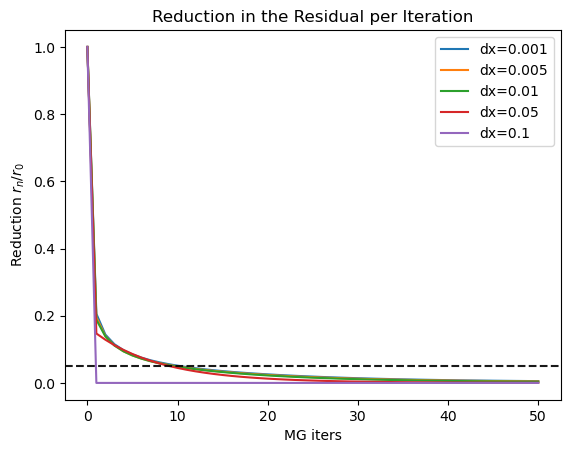

In [16]:
# Test convergence of multigrid
fig, ax = plt.subplots(1, 1)
L = 2
dxs = [0.001, 0.005, 0.01, 0.05, 0.1]
for i in range(len(dxs)):
    BurgersSolver = Burgers_FV(L, dxs[i], u_0)
    residuals = BurgersSolver.testMultigrid(dt=0.01, iters=50)
    ax.plot(np.arange(len(residuals)), np.array(residuals)/residuals[0], label=f"dx={dxs[i]}")
ax.legend()
ax.axhline(y=0.05, color='k', ls='--', alpha=0.9)
ax.set_xlabel("MG iters")
ax.set_ylabel(r"Reduction $r_n/r_0$")
ax.set_title("Reduction in the Residual per Iteration")
print(f"Residuals: {residuals}")
plt.show()